In [5]:
# ============================================================
# 0. Imports, project discovery, style, and output directories
# ============================================================
from pathlib import Path
import os, json, csv, math, warnings
from collections import defaultdict

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import PchipInterpolator
from scipy.integrate import solve_ivp
from scipy.linalg import expm

HISTORICAL_PROJECT_ROOT = Path("/home/smohtash/H2X2_final/H2X2_publication_project")

def looks_like_project(path):
    path = Path(path)
    return all((path / "data" / m).is_dir() for m in ("H2O2", "H2S2", "H2Se2"))

def locate_project_root():
    candidates = []
    if os.environ.get("H2X2_PROJECT_ROOT"):
        candidates.append(Path(os.environ["H2X2_PROJECT_ROOT"]).expanduser())
    candidates += [
        HISTORICAL_PROJECT_ROOT,
        Path.cwd() / "H2X2_publication_project",
        Path.cwd(),
        Path.cwd().parent / "H2X2_publication_project",
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if looks_like_project(candidate):
            return candidate
    tested = "\n".join(f"  - {Path(p).expanduser()}" for p in candidates)
    raise FileNotFoundError(
        "Could not locate the H2X2 publication project. Set the environment variable\n"
        "H2X2_PROJECT_ROOT to the directory containing data/H2O2, data/H2S2,\n"
        f"and data/H2Se2. Paths tested:\n{tested}"
    )

PROJECT_ROOT = locate_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
COMBINED_ROOT = PROJECT_ROOT / "combined"
FIG_DIR = COMBINED_ROOT / "figures_maintext"
FIGDATA_DIR = COMBINED_ROOT / "figure_data_maintext"
for directory in (FIG_DIR, FIGDATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MOLECULES = ["H2O2", "H2S2", "H2Se2"]
LABELS = {"H2O2": r"H$_2$O$_2$", "H2S2": r"H$_2$S$_2$", "H2Se2": r"H$_2$Se$_2$"}
COLORS = {"H2O2": "#0072B2", "H2S2": "#D55E00", "H2Se2": "#009E73"}

HARTREE_TO_CM = 219474.6313705
C_CM_S = 2.99792458e10
KB_SI = 1.380649e-23
AMU_KG = 1.66053906660e-27
QSTAR = 74.8
RWA_R1 = 0.1654
LR_PHASE_DEG = 85.8946

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9.5,
    "axes.labelsize": 10.0,
    "axes.titlesize": 10.5,
    "legend.fontsize": 8.0,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "figure.dpi": 130,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def save_figure(fig, stem):
    pdf = FIG_DIR / f"{stem}.pdf"
    png = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("Saved:", pdf)
    print("Saved:", png)
    return pdf, png

print("Resolved project root:", PROJECT_ROOT)
print("Figure directory:", FIG_DIR)

Resolved project root: /home/smohtash/H2X2_final/H2X2_publication_project
Figure directory: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figures_maintext


In [6]:
# ============================================================
# 1. Load exactly the same molecule archives as Notebook 4
# ============================================================
summaries, dvr, surfaces, scans = {}, {}, {}, {}

required_npz = {
    "phi_rad", "chi_rad", "V_ha", "Ee_ha", "Eo_ha", "Pe", "Po",
    "mu_z_D", "Delta_cm", "I_chi_amu_bohr2"
}

for molecule in MOLECULES:
    root = DATA_ROOT / molecule
    paths = {
        "summary": root / "processed" / "summary.json",
        "dvr": root / "processed" / "dvr_wavefunctions.npz",
        "surface": root / "processed" / "dvr_surface.csv",
        "scan": root / "raw" / "torsion_scan.csv",
        "qz": root / "validation" / "qz_path_correction.csv",
    }
    missing = [p for key, p in paths.items() if key != "qz" and not p.exists()]
    if missing:
        raise FileNotFoundError(f"{molecule}: missing required production files: {missing}")

    summaries[molecule] = json.loads(paths["summary"].read_text())
    with np.load(paths["dvr"]) as archive:
        dvr[molecule] = {key: archive[key] for key in archive.files}
    missing_keys = sorted(required_npz - set(dvr[molecule]))
    if missing_keys:
        raise KeyError(f"{paths['dvr']} is missing NPZ keys: {missing_keys}")

    surfaces[molecule] = np.genfromtxt(
        paths["surface"], delimiter=",", names=True, encoding=None
    )
    scans[molecule] = np.genfromtxt(
        paths["scan"], delimiter=",", names=True, encoding=None
    )

    print(f"\n{molecule}")
    print("  DVR archive:", paths["dvr"])
    print("  NPZ keys:", sorted(dvr[molecule]))
    print("  dvr_surface.csv columns:", list(surfaces[molecule].dtype.names or []))
    print("  torsion_scan.csv columns:", list(scans[molecule].dtype.names or []))
    print("  sparse-QZ path:", paths["qz"] if paths["qz"].exists() else "not archived")

print("\nAll three saved DVR archives loaded successfully.")


H2O2
  DVR archive: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/processed/dvr_wavefunctions.npz
  NPZ keys: ['Delta_cm', 'Delta_cm_signed', 'Ee_ha', 'Eo_ha', 'I_COM_only_amu_bohr2', 'I_chi_amu_bohr2', 'Ieff_amu_bohr2', 'L', 'L_density_per_rad', 'Pe', 'Po', 'R', 'R_density_per_rad', 'V_ha', 'chi_rad', 'mu01_D', 'mu_z_D', 'phi_rad']
  dvr_surface.csv columns: ['grid_index', 'chi_rad', 'phi_rad', 'phi_deg', 'V_ha', 'V_cm1', 'Ieff_amu_bohr2', 'I_COM_only_amu_bohr2', 'mu_z_D']
  torsion_scan.csv columns: ['phi_deg', 'RXX_A', 'RXH_A', 'theta_deg', 'E_MP2_ha', 'E_CCSDT_ha', 'E_used_ha', 'rel_cm1', 'rel_kcal_mol', 'mu_x_D', 'mu_y_D', 'mu_z_D', 'T1_diagnostic', 'optimizer_nfev', 'optimizer_elapsed_s', 'ccsdt_elapsed_s', 'dipole_elapsed_s']
  sparse-QZ path: not archived

H2S2
  DVR archive: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2S2/processed/dvr_wavefunctions.npz
  NPZ keys: ['Delta_cm', 'Delta_cm_signed', 'Ee_ha', 'Eo_ha', 'I_COM_only_amu_bohr2', 'I_chi_amu

In [7]:
# ============================================================
# 2. Generic schema, symmetry, interpolation, and DVR helpers
# ============================================================
def _as_1d_structured(array):
    return np.array([array], dtype=array.dtype) if np.ndim(array) == 0 else array

def _norm_name(name):
    return "".join(ch.lower() for ch in str(name) if ch.isalnum())

def resolve_column(table, aliases, required_tokens=(), forbidden_tokens=()):
    names = list(table.dtype.names or [])
    normalized = {_norm_name(name): name for name in names}
    for alias in aliases:
        if _norm_name(alias) in normalized:
            return normalized[_norm_name(alias)]
    matches = []
    for name in names:
        n = _norm_name(name)
        if all(_norm_name(t) in n for t in required_tokens) and not any(
            _norm_name(t) in n for t in forbidden_tokens
        ):
            matches.append(name)
    if len(matches) == 1:
        return matches[0]
    raise KeyError(
        f"Could not identify a unique column. Aliases={aliases}; "
        f"tokens={required_tokens}; available={names}; matches={matches}"
    )

def energy_to_relative_cm(values, column_name):
    values = np.asarray(values, float)
    name = _norm_name(column_name)
    if "kcal" in name:
        factor = 1.0 / 0.002859144
    elif "cm" in name or "wavenumber" in name:
        factor = 1.0
    else:
        factor = HARTREE_TO_CM
    return (values - np.nanmin(values)) * factor

def sorted_unique(x, *ys):
    x = np.asarray(x, float)
    order = np.argsort(x)
    x = x[order]
    ys = [np.asarray(y)[order] for y in ys]
    ux = np.unique(x)
    out = []
    for y in ys:
        out.append(np.array([np.mean(y[np.isclose(x, u)]) for u in ux]))
    return (ux, *out)

def full_symmetric_branch(phi_deg, *arrays):
    phi_deg, *arrays = sorted_unique(phi_deg, *arrays)
    if np.nanmin(phi_deg) < -1e-6:
        return (phi_deg, *arrays)
    interior = (phi_deg > 1e-9) & (phi_deg < 180 - 1e-9)
    full_phi = np.concatenate((-phi_deg[interior][::-1], phi_deg))
    full_arrays = [np.concatenate((a[interior][::-1], a)) for a in arrays]
    return (full_phi, *full_arrays)

def periodic_phi_jacobian(phi_rad, chi_rad):
    # Both saved arrays are sampled in the uniform-chi ordering.
    phi_u = np.unwrap(np.asarray(phi_rad, float))
    chi_u = np.unwrap(np.asarray(chi_rad, float))
    dphi_dchi = np.gradient(phi_u, chi_u, edge_order=2)
    if np.any(~np.isfinite(dphi_dchi)) or np.any(np.abs(dphi_dchi) < 1e-12):
        raise RuntimeError("Invalid dphi/dchi in saved arc-coordinate mapping")
    jac = np.abs(1.0 / dphi_dchi)
    return jac

def parity_sorted_states(molecule, n_show=6):
    z = dvr[molecule]
    records = []
    for parity, energies, vectors in (
        ("even", np.asarray(z["Ee_ha"], float), np.asarray(z["Pe"], complex)),
        ("odd",  np.asarray(z["Eo_ha"], float), np.asarray(z["Po"], complex)),
    ):
        for sector_index, energy in enumerate(energies):
            records.append({
                "parity": parity,
                "sector_index": sector_index,
                "E_ha": float(energy),
                "vec_chi": vectors[:, sector_index].copy(),
            })
    records.sort(key=lambda row: row["E_ha"])
    jac = periodic_phi_jacobian(z["phi_rad"], z["chi_rad"])
    for v, row in enumerate(records[:n_show]):
        psi = row["vec_chi"] * np.sqrt(jac)
        k = int(np.argmax(np.abs(psi)))
        psi *= np.exp(-1j * np.angle(psi[k]))
        psi = np.real_if_close(psi, tol=1000).real
        k = int(np.argmax(np.abs(psi)))
        if psi[k] < 0:
            psi *= -1
        amp = float(np.max(np.abs(psi)))
        row.update(v=v, E_cm=row["E_ha"] * HARTREE_TO_CM,
                   psi_phi_display=psi / amp if amp else psi)
    return records[:n_show]

def surface_arrays(molecule):
    table = _as_1d_structured(surfaces[molecule])
    phi_col = resolve_column(table, ["phi_deg", "dihedral_deg", "torsion_deg"])
    v_col = resolve_column(table, ["V_cm1", "V_cm-1", "potential_cm1"], required_tokens=("v", "cm"))
    phi = np.asarray(table[phi_col], float)
    potential = np.asarray(table[v_col], float)
    return sorted_unique(phi, potential)

def scan_energy_arrays(molecule):
    table = _as_1d_structured(scans[molecule])
    phi_col = resolve_column(table, ["phi_deg", "dihedral_deg", "torsion_deg", "phi"])
    mp2_col = resolve_column(
        table,
        ["E_MP2_ha", "E_mp2_total_ha", "mp2_energy_ha", "emp2_ha", "mp2_ha"],
        required_tokens=("mp2",), forbidden_tokens=("ccsd", "delta")
    )
    try:
        ccsdt_col = resolve_column(
            table,
            ["E_CCSDT_ha", "E_CCSD_T_ha", "E_ccsd_t_total_ha", "ccsdt_energy_ha", "eccsdt_ha"],
            required_tokens=("ccsd", "t"), forbidden_tokens=("corr", "delta", "qz")
        )
    except KeyError:
        ccsdt_col = None
    phi = np.asarray(table[phi_col], float)
    mp2_raw = np.asarray(table[mp2_col], float)
    ccsdt_raw = np.asarray(table[ccsdt_col], float) if ccsdt_col else None
    return phi, mp2_raw, ccsdt_raw, mp2_col, ccsdt_col

def qz_path_arrays(molecule):
    path = DATA_ROOT / molecule / "validation" / "qz_path_correction.csv"
    if not path.exists():
        return None
    table = _as_1d_structured(np.genfromtxt(path, delimiter=",", names=True, encoding=None))
    phi_col = resolve_column(table, ["phi_deg", "dihedral_deg", "torsion_deg"])
    corr_col = resolve_column(
        table,
        ["delta_QZ_minus_TZ_ha", "qz_minus_tz_ha", "delta_qz_tz_ha"],
        required_tokens=("qz", "tz"), forbidden_tokens=("cm", "kcal")
    )
    return sorted_unique(np.asarray(table[phi_col], float), np.asarray(table[corr_col], float))

def qz_splitting_table():
    path = COMBINED_ROOT / "tables" / "QZ_corrected_tunneling_sensitivity.csv"
    rows = defaultdict(list)
    if path.exists():
        with path.open(newline="") as handle:
            for row in csv.DictReader(handle):
                rows[row["molecule"]].append(row)
    result = {}
    for molecule in MOLECULES:
        production = abs(float(summaries[molecule]["tunneling"]["DVR_predicted_cm-1"]))
        benchmark = float(summaries[molecule]["tunneling"]["benchmark_primary_cm-1"])
        qz = np.nan
        for row in rows.get(molecule, []):
            if row.get("surface") == "QZ_corrected_sparse_path":
                qz = float(row["Delta_cm-1"])
        finite = [x for x in (production, qz) if np.isfinite(x)]
        result[molecule] = {
            "production": production,
            "qz": qz,
            "lo": min(finite),
            "hi": max(finite),
            "benchmark": benchmark,
        }
    return result

QZ_SPLITTINGS = qz_splitting_table()

Saved: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figures_maintext/Fig01_complete_torsional_quantum_picture.pdf
Saved: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figures_maintext/Fig01_complete_torsional_quantum_picture.png


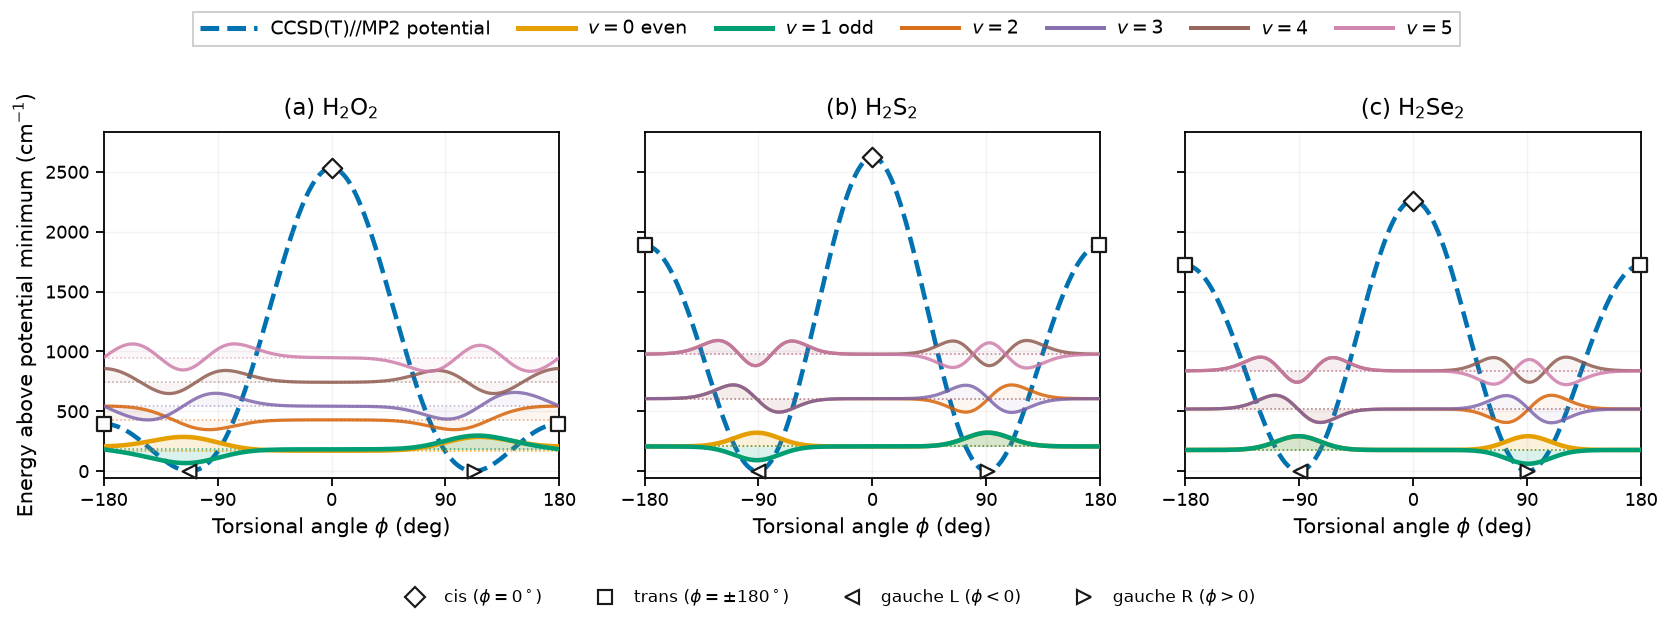

Saved source data: /home/smohtash/H2X2_final/H2X2_publication_project/combined/figure_data_maintext/Fig01_DVR_states.csv


In [12]:
# ============================================================
# FIGURE 1: potential + parity-resolved DVR states + markers
# ============================================================
import csv
from matplotlib.lines import Line2D

N_SHOW = 6
WAVE_SCALE_CM = 115.0

# Saturated, colorblind-friendly palette matching Figure 2's visual weight.
POTENTIAL_COLOR = "#0072B2"
STATE_COLORS = {
    0: "#E69F00",  # orange
    1: "#009E73",  # green
    2: "#D55E00",  # vermillion
    3: "#7B61A8",  # purple
    4: "#8C564B",  # brown
    5: "#CC79A7",  # reddish purple
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.2, 4.9),
    sharey=True,
)

figure_rows = []

for panel, (ax, molecule) in enumerate(zip(axes, MOLECULES)):

    phi, potential = surface_arrays(molecule)

    order = np.argsort(phi)
    phi = phi[order]
    potential = potential[order]

    # --------------------------------------------------------
    # Electronic potential
    # --------------------------------------------------------
    ax.plot(
        phi,
        potential,
        color=POTENTIAL_COLOR,
        linestyle="--",
        linewidth=2.5,
        label="CCSD(T)//MP2 potential",
        zorder=1,
    )

    states = parity_sorted_states(molecule, N_SHOW)

    dvr_phi = np.rad2deg(
        np.asarray(dvr[molecule]["phi_rad"], dtype=float)
    )
    porder = np.argsort(dvr_phi)
    dvr_phi = dvr_phi[porder]

    # --------------------------------------------------------
    # DVR energy levels and displaced eigenfunctions
    # --------------------------------------------------------
    for state in states:

        v = state["v"]
        energy_cm = state["E_cm"]
        psi = state["psi_phi_display"][porder]

        display_y = energy_cm + WAVE_SCALE_CM * psi
        state_color = STATE_COLORS[v]

        if v < 2:
            linewidth = 2.5
            alpha = 1.0
            fill_alpha = 0.14
            level_alpha = 0.82
            zorder = 5
        else:
            linewidth = 1.8
            alpha = 0.82
            fill_alpha = 0.06
            level_alpha = 0.52
            zorder = 3

        ax.plot(
            dvr_phi,
            display_y,
            color=state_color,
            linestyle="-",
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
        )

        ax.hlines(
            energy_cm,
            -180,
            180,
            color=state_color,
            linestyle=":",
            linewidth=0.85,
            alpha=level_alpha,
            zorder=2,
        )

        ax.fill_between(
            dvr_phi,
            energy_cm,
            display_y,
            color=state_color,
            alpha=fill_alpha,
            linewidth=0,
            zorder=zorder - 1,
        )

        for phi_value, y_value, psi_value in zip(
            dvr_phi,
            display_y,
            psi,
        ):
            figure_rows.append(
                [
                    molecule,
                    v,
                    state["parity"],
                    energy_cm,
                    phi_value,
                    psi_value,
                    y_value,
                ]
            )

    # --------------------------------------------------------
    # Structural locations
    # --------------------------------------------------------
    positive_mask = phi >= 0

    right_index = np.where(positive_mask)[0][
        np.argmin(potential[positive_mask])
    ]
    right_phi = float(phi[right_index])
    right_y = float(potential[right_index])

    left_index = int(np.argmin(np.abs(phi + right_phi)))
    left_phi = float(phi[left_index])
    left_y = float(potential[left_index])

    cis_index = int(np.argmin(np.abs(phi)))
    cis_phi = float(phi[cis_index])
    cis_y = float(potential[cis_index])

    trans_left_index = int(np.argmin(np.abs(phi + 180.0)))
    trans_right_index = int(np.argmin(np.abs(phi - 180.0)))

    trans_left_phi = float(phi[trans_left_index])
    trans_right_phi = float(phi[trans_right_index])

    trans_left_y = float(potential[trans_left_index])
    trans_right_y = float(potential[trans_right_index])

    marker_kw = {
        "s": 58,
        "facecolor": "white",
        "edgecolor": "0.10",
        "linewidth": 1.25,
        "zorder": 8,
        "clip_on": False,
    }

    # cis
    ax.scatter(
        [cis_phi],
        [cis_y],
        marker="D",
        **marker_kw,
    )

    # trans
    ax.scatter(
        [trans_left_phi, trans_right_phi],
        [trans_left_y, trans_right_y],
        marker="s",
        **marker_kw,
    )

    # gauche L and R
    ax.scatter(
        [left_phi],
        [left_y],
        marker="<",
        **marker_kw,
    )

    ax.scatter(
        [right_phi],
        [right_y],
        marker=">",
        **marker_kw,
    )

    # --------------------------------------------------------
    # Axes formatting
    # --------------------------------------------------------
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xlabel(
        r"Torsional angle $\phi$ (deg)",
        fontsize=11.5,
    )
    ax.set_title(
        f"({chr(97 + panel)}) {LABELS[molecule]}",
        fontsize=12.5,
        loc="center",
        pad=9,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=10,
        width=1.0,
        length=4.5,
    )

    ax.grid(
        alpha=0.15,
        linewidth=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

axes[0].set_ylabel(
    r"Energy above potential minimum (cm$^{-1}$)",
    fontsize=11.5,
)

ymax = max(
    float(np.max(surface_arrays(molecule)[1]))
    for molecule in MOLECULES
)
axes[0].set_ylim(-55, 1.08 * ymax)

# ============================================================
# DVR-state legend above the panels
# ============================================================
state_legend_handles = [
    Line2D(
        [0],
        [0],
        color=POTENTIAL_COLOR,
        linewidth=2.8,
        linestyle="--",
        label="CCSD(T)//MP2 potential",
    ),
    *[
        Line2D(
            [0],
            [0],
            color=STATE_COLORS[v],
            linewidth=2.8 if v < 2 else 2.2,
            alpha=1.0 if v < 2 else 0.90,
            label=(
                rf"$v={v}$ even"
                if v == 0
                else rf"$v={v}$ odd"
                if v == 1
                else rf"$v={v}$"
            ),
        )
        for v in range(N_SHOW)
    ],
]

fig.legend(
    handles=state_legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=7,
    frameon=True,
    fancybox=False,
    facecolor="white",
    edgecolor="0.80",
    framealpha=1.0,
    fontsize=10.5,
    handlelength=3.0,
    handletextpad=0.7,
    columnspacing=1.45,
    borderpad=0.38,
)

# ============================================================
# Structural legend below the panels
# ============================================================
structure_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="D",
        markersize=7.5,
        markerfacecolor="white",
        markeredgecolor="0.10",
        markeredgewidth=1.2,
        linestyle="none",
        label=r"cis ($\phi=0^\circ$)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        markersize=7.5,
        markerfacecolor="white",
        markeredgecolor="0.10",
        markeredgewidth=1.2,
        linestyle="none",
        label=r"trans ($\phi=\pm180^\circ$)",
    ),
    Line2D(
        [0],
        [0],
        marker="<",
        markersize=8.0,
        markerfacecolor="white",
        markeredgecolor="0.10",
        markeredgewidth=1.2,
        linestyle="none",
        label=r"gauche L ($\phi<0$)",
    ),
    Line2D(
        [0],
        [0],
        marker=">",
        markersize=8.0,
        markerfacecolor="white",
        markeredgecolor="0.10",
        markeredgewidth=1.2,
        linestyle="none",
        label=r"gauche R ($\phi>0$)",
    ),
]

fig.legend(
    handles=structure_legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=4,
    frameon=False,
    fontsize=9.5,
    handletextpad=0.7,
    columnspacing=2.6,
)

# Reserve compact rows for the two legends.
fig.tight_layout(
    rect=[0.015, 0.115, 0.995, 0.865],
    w_pad=2.6,
)

save_figure(
    fig,
    "Fig01_complete_torsional_quantum_picture",
)

plt.show()

# ============================================================
# Save figure-source data
# ============================================================
out = FIGDATA_DIR / "Fig01_DVR_states.csv"

with out.open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(
        [
            "molecule",
            "v",
            "parity",
            "energy_cm-1",
            "phi_deg",
            "psi_phi_normalized_for_display",
            "display_y_cm-1",
        ]
    )
    writer.writerows(figure_rows)

print("Saved source data:", out)
